<div class="dark-title" style="background:linear-gradient(90deg,#1e3a8a,#5b21b6); color:#f1f5f9; padding:20px 32px; border-radius:8px; width:97%;"><style>.dark-title strong{color:#fde047;}</style>

## 🎯 LangGraph 101 — 入门基础

**一句话定位**:LangGraph 是搭建 **workflow + agent** 的低层框架,跟 LangChain(模型接入)、LangSmith(可观测性)一起组成完整生态。

</div>

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**📚 这一节会学到**

- LangGraph 的 **三件套**:State / Node / Edge
- 如何用它搭 **workflow**(预定义路径)和 **agent**(LLM 自主循环)
- **持久化层**:checkpointer 让多轮对话 / 暂停成为可能
- **interrupts**:让人类介入做关键决策(HITL 的基石)
- 如何用 **LangSmith** 自动追踪、用 **LangGraph Platform** 部署

</div>

![ecosystem](./img/ecosystem.png)

## 💬 Chat Models(对话模型)

[Chat models](https://python.langchain.com/docs/concepts/chat_models/) 是 LLM 应用的基础。它们通过一个 chat 接口接受 **消息列表**(messages)作为输入,返回 **一条消息**(message)作为输出。

LangChain 提供了 [统一的 chat models 接口 `init_chat_model`](https://python.langchain.com/api_reference/langchain/chat_models/langchain.chat_models.base.init_chat_model.html),让你能 [一行换 provider](https://python.langchain.com/docs/integrations/chat/)。

<div class="dark-cyan" style="background:#0f2729; color:#a5f3fc; padding:10px 24px; border-left:4px solid #22d3ee; border-radius:4px; width:97%;"><style>.dark-cyan strong{color:#fbbf24;}</style>

**🆕 2026 年提示**:LangChain 1.0+ 已发布,`langchain.chat_models.init_chat_model` 是接入任何模型的标准入口。常见用法:

- `init_chat_model("openai:gpt-4o")`
- `init_chat_model("anthropic:claude-sonnet-4-5")`
- `init_chat_model("google_genai:gemini-2.5-pro")`

</div>

In [1]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [2]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("openai:gpt-4.1", temperature=0)

## 🚀 调用模型

`init_chat_model` 接口为 chat models 提供了 [标准化方法](https://python.langchain.com/docs/concepts/runnables/),最常用的两个:

| 方法 | 行为 |
|------|------|
| `invoke()` | **单次输入 → 单次输出**(同步) |
| `stream()` | 输出 **流式产生**(按 token 一边算一边返回) |
| `batch()` | 批量同时处理多条输入 |
| `ainvoke()` / `astream()` | 上面两个的 **异步版** |

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

💡 **学习建议**:你 95% 的时间只会用 `invoke()`。`stream()` 在做聊天 UI 时才需要。

</div>

In [3]:
result = llm.invoke("What is an agent?")

In [4]:
type(result)

langchain_core.messages.ai.AIMessage

In [5]:
from rich.markdown import Markdown
Markdown(result.content)

The term "agent" can have different meanings depending on the context. Here are some common definitions:           

1. General Definition                                                                                              

An agent is someone or something that acts on behalf of another or has the power to act. It is an entity that does 
something or causes something to happen.                                                                           

2. In Artificial Intelligence (AI) and Computer Science                                                            

An agent is a system or program that perceives its environment through sensors and acts upon that environment      
through actuators to achieve specific goals. For example:                                                          

 • A software agent might be a program that searches the internet for information.                                 
 • An intelligent agent can make decisions and learn from its environment.                                         

3. In Business and Law                                                                                             

An agent is a person authorized to act on behalf of another (the principal) in business transactions. For example: 

 • A real estate agent helps buy or sell property for clients.                                                     
 • A travel agent arranges travel plans for customers.                                                             

4. In Chemistry and Biology                                                                                        

An agent can refer to a substance that brings about a chemical or biological effect, such as:                      

 • A cleaning agent (a chemical used for cleaning)                                                                 
 • An infectious agent (a microorganism that causes disease)                                                       

-------------------------------------------------------------------------------------------------------------------

Summary:                                                                                                           
An agent is generally an entity (person, program, or thing) that acts, makes decisions, or causes effects, often on
behalf of someone or something else. The specific meaning depends on the field or context.

## 🔧 Tools(工具)

[Tools](https://python.langchain.com/docs/concepts/tools/) 是 chat model 可以调用的 **外部能力**。在 LangChain 中,创建工具最常见的方式是用 `@tool` 装饰器:

- 把任意 Python 函数 **包装** 成工具
- **自动推断** 工具的 name、description、参数 schema —— 这些信息会被传给 LLM,让它知道这个工具能干嘛、怎么调

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🆕 MCP(Model Context Protocol)在 2026 年大火**

除了 `@tool` 包 Python 函数,你还可以用 [MCP servers](https://github.com/langchain-ai/langchain-mcp-adapters) 接入第三方工具(跨语言、跨进程)。MCP 在 2024 年底由 Anthropic 推出,2026 年已经成为 agent 接入工具的事实标准 —— 一处写好,任何 LLM/agent 都能用。

</div>

In [6]:
from langchain.tools import tool

@tool
def write_email(to: str, subject: str, content: str) -> str:
    """Write and send an email."""
    # Placeholder response - in real app would send email
    return f"Email sent to {to} with subject '{subject}' and content: {content}"

In [7]:
type(write_email)

langchain_core.tools.structured.StructuredTool

In [8]:
write_email.args

{'to': {'title': 'To', 'type': 'string'},
 'subject': {'title': 'Subject', 'type': 'string'},
 'content': {'title': 'Content', 'type': 'string'}}

In [9]:
Markdown(write_email.description)

Write and send an email.

## 🛠️ Tool Calling(工具调用)

工具 [被 LLM 调用](https://python.langchain.com/docs/concepts/tool_calling/) 的过程其实很微妙——**LLM 并不直接执行工具**,它只是输出一个 **结构化的参数 JSON**,告诉你"我想调这个工具,参数是这些"。真正执行,是你(或框架)拿到这个 tool_call 后再去跑工具。

把工具挂到 LLM 上,用的是 `bind_tools` 方法:

![tool-img](img/tool_call_detail.png)

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 两个重要参数(强烈建议显式设置)**

- `tool_choice="any"` —— **强制** LLM 至少调一个可用工具(默认是"LLM 自己决定调不调")
- `parallel_tool_calls=False` —— **限制** LLM 一次只调一个工具(默认允许并行多个)

这两个参数在生产场景里是 **必备控制器**:HITL 场景要 `parallel_tool_calls=False`(否则一次拦截多个工具难处理);agent 循环要 `tool_choice="any"`(否则 LLM 可能输出纯文本不调工具,流程卡住)。

</div>

📎 详见 [`tool_choice` 文档](https://python.langchain.com/docs/how_to/tool_choice/) 和 [并行调用控制](https://python.langchain.com/docs/how_to/tool_calling_parallel/)。

In [10]:
# Connect tools to a chat model
model_with_tools = llm.bind_tools([write_email], tool_choice="any", parallel_tool_calls=False)

# The model will now be able to call tools
output = model_with_tools.invoke("Draft a response to my boss (boss@company.ai) about tomorrow's meeting")

In [11]:
type(output)

langchain_core.messages.ai.AIMessage

In [12]:
output

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 67, 'total_tokens': 159, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_ba08f5cdbb', 'id': 'chatcmpl-DgV4Ofp7hzQB6XwtmtpHfX3qdL3uB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e35f3-04c1-7851-8a07-a5c63bd9122c-0', tool_calls=[{'name': 'write_email', 'args': {'to': 'boss@company.ai', 'subject': "Re: Tomorrow's Meeting", 'content': "Hello,\n\nThank you for the reminder about tomorrow's meeting. I confirm my attendance and will be prepared with the necessary updates and materials.\n\nPlease let me know if there is anything specific you would like me to focus on o

In [13]:
# Extract tool calls and execute them
args = output.tool_calls[0]['args']
args

{'to': 'boss@company.ai',
 'subject': "Re: Tomorrow's Meeting",
 'content': "Hello,\n\nThank you for the reminder about tomorrow's meeting. I confirm my attendance and will be prepared with the necessary updates and materials.\n\nPlease let me know if there is anything specific you would like me to focus on or bring to the discussion.\n\nBest regards,\n\n[Your Name]"}

In [14]:
# Call the tool
result = write_email.invoke(args)
Markdown(result)

Email sent to boss@company.ai with subject 'Re: Tomorrow's Meeting' and content: Hello,                            

Thank you for the reminder about tomorrow's meeting. I confirm my attendance and will be prepared with the         
necessary updates and materials.                                                                                   

Please let me know if there is anything specific you would like me to focus on or bring to the discussion.         

Best regards,                                                                                                      

[Your Name]

![basic_prompt](img/tool_call.png)

## 🔀 Workflows(工作流)

构建 LLM 应用有 **很多模式**。最简单的是 [把 LLM 调用嵌进 **预定义的代码路径**](https://langchain-ai.github.io/langgraph/tutorials/workflows/),给系统一定的"自主性"做决策,但 **路径是你写死的**。

举例:在调用 `send_email` 工具前,加一个 **router 节点**判断要不要回这封邮件。

![workflow_example](img/workflow_example.png)

## 🤖 Agents

进一步放权 —— 让 LLM **自己决定** 调哪些工具、按什么顺序。

[Agent](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) 通常实现为 **工具调用的循环**:每次 tool 调用的结果反馈给 LLM,LLM 决定下一步;循环直到不再调工具为止。

![agent_example](img/agent_example.png)

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**💎 Lance 的核心准则**:

- **能在白板上画清楚控制流** → 用 **workflow**(快、便宜、可预测)
- **运行时才知道怎么走** → 用 **agent**(灵活,但更慢、更贵、可预测性差)

</div>

![workflow_v_agent](img/workflow_v_agent.png)

## ❓ 什么是 LangGraph?

[LangGraph](https://langchain-ai.github.io/langgraph/concepts/high_level/) 是一个 **低层基础设施**,坐在 *任何* workflow 或 agent 的下面。

它 **不抽象** prompt、**不规定** 架构,只提供三大好处:

| 好处 | 含义 |
|------|------|
| **Control(控制)** | 让你能轻松定义并组合 workflow 和 agent |
| **Persistence(持久化)** | 保存图的状态 → 实现 **memory** + **human-in-the-loop** |
| **Testing / Debugging / Deployment** | 测试、调试、部署应用的简单入口 |

### 🧱 Control —— 三件套

LangGraph 让你把应用定义成一个 graph,核心是 **三件套**:

1. **State** —— 整个应用里要追踪的信息(schema)
2. **Nodes** —— 怎么更新这些信息
3. **Edges** —— 怎么把节点连起来

用 [`StateGraph` 类](https://langchain-ai.github.io/langgraph/concepts/low_level/#graphs) 初始化一个 LangGraph 图,需要传入一个 [`State` object](https://langchain-ai.github.io/langgraph/concepts/low_level/#state)。

**State 可以是任何带 `getattr()` 的对象**:

| 选项 | 速度 | 默认值 | 类型验证 |
|------|------|--------|----------|
| `TypedDict` | 最快 | ❌ 不支持 | ❌ |
| `@dataclass` | 几乎一样快 | ✅ | ❌ |
| `pydantic.BaseModel` | 稍慢 | ✅ | ✅(尤其用 validator 时) |

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

💡 **新手默认选 `TypedDict`**;需要默认值用 `dataclass`;需要严格校验(对接 API)用 Pydantic。

</div>

In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class StateSchema(TypedDict):
    request: str
    email: str

workflow = StateGraph(StateSchema)

**Node(节点)的本质**:每个 node 就是一段 Python 函数(TypeScript 也可以)。函数体逻辑完全由你掌控。

- **输入**:当前的 state
- **输出**:一个 `dict`,用来 **更新 state**

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 默认行为是「**覆盖**」,不是「**追加**」**

[默认,state 的 key 会被新返回值覆盖](https://langchain-ai.github.io/langgraph/how-tos/state-reducers/)。如果你想自定义合并逻辑(比如 messages 列表自动 append),需要 [定义 reducer](https://langchain-ai.github.io/langgraph/concepts/low_level/#reducers)。

最常见的 reducer 是 `add_messages` —— 它被 `MessagesState` 默认装上,所以 messages 才会自动累积。

</div>

![nodes_edges](img/nodes_edges.png)

In [16]:
def write_email_node(state: StateSchema) -> StateSchema:
    # Imperative code that processes the request
    output = model_with_tools.invoke(state["request"])
    args = output.tool_calls[0]['args']
    email = write_email.invoke(args)
    return {"email": email}

**Edge(边)** 把节点连起来。

你通过 **添加 nodes 和 edges** 到 state graph 来定义控制流。三种基础 edge:

| 边类型 | 写法 | 用途 |
|--------|------|------|
| **起点边** | `add_edge(START, "node_a")` | 入口固定 |
| **直连边** | `add_edge("a", "b")` | 永远从 a 到 b,无分支 |
| **条件边** | `add_conditional_edges("a", router_fn)` | **运行时决定** 下一个节点 |

In [17]:
workflow = StateGraph(StateSchema)
workflow.add_node("write_email_node", write_email_node)
workflow.add_edge(START, "write_email_node")
workflow.add_edge("write_email_node", END)

app = workflow.compile()

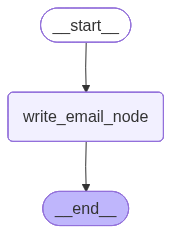

In [19]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [18]:
app.invoke({"request": "Draft a response to my boss (boss@company.ai) about tomorrow's meeting"})

{'request': "Draft a response to my boss (boss@company.ai) about tomorrow's meeting",
 'email': "Email sent to boss@company.ai with subject 'Re: Tomorrow's Meeting' and content: Hello,\n\nThank you for the reminder about tomorrow's meeting. I confirm my attendance and will be prepared with the necessary updates and materials.\n\nPlease let me know if there is anything specific you would like me to focus on or bring to the discussion.\n\nBest regards,\n\n[Your Name]"}

**条件边(Conditional Edges)** 让节点之间的路由 [按需决策](https://langchain-ai.github.io/langgraph/concepts/low_level/#conditional-edges)。

机制很简单:

- 你写一个 **路由函数**(接受 state,返回下一个 node 的 **名字** 或 **名字列表**)
- 返回 list 时,会 **并行 fan-out** 给多个节点

可选地,你还能传一个 dict,把路由函数的返回值映射到 node 名(`should_continue` 输出 `"continue"` → 实际跳到 `"tool_handler"`)。

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**💡 Node 返回 vs Edge 返回 —— 别搞混**

- **Node 返回 dict** → 更新 state(键值)
- **Conditional edge 返回字符串** → 下一个 node 的 **名字**(不是 state 更新!)

</div>

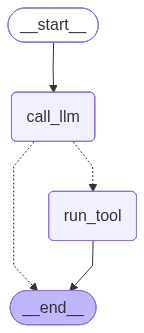

In [22]:
from typing import Literal
from langgraph.graph import MessagesState
import sys
sys.path.append("../src")
from email_assistant.utils import show_graph

def call_llm(state: MessagesState) -> MessagesState:
    """Run LLM"""

    output = model_with_tools.invoke(state["messages"])
    return {"messages": [output]}

def run_tool(state: MessagesState):
    """Performs the tool call"""

    result = []
    for tool_call in state["messages"][-1].tool_calls:
        observation = write_email.invoke(tool_call["args"])
        result.append({"role": "tool", "content": observation, "tool_call_id": tool_call["id"]})
    return {"messages": result}

def should_continue(state: MessagesState) -> Literal["run_tool", "__end__"]:
    """Route to tool handler, or end if Done tool called"""
    
    # Get the last message
    messages = state["messages"]
    last_message = messages[-1]
    
    # If the last message is a tool call, check if it's a Done tool call
    if last_message.tool_calls:
        return "run_tool"
    # Otherwise, we stop (reply to the user)
    return END

workflow = StateGraph(MessagesState)
workflow.add_node("call_llm", call_llm)
workflow.add_node("run_tool", run_tool)
workflow.add_edge(START, "call_llm")
workflow.add_conditional_edges("call_llm", should_continue, {"run_tool": "run_tool", END: END})
workflow.add_edge("run_tool", END)

# Run the workflow
app = workflow.compile()

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

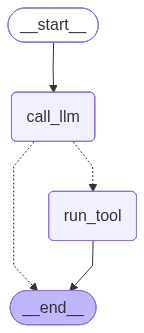

In [23]:
show_graph(app)

In [24]:
result = app.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!",
            }
        ]
    }
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!
================================== Ai Message ==================================
Tool Calls:
  write_email (call_Ms8ftmVo6wOw4s2sNxej0BBa)
 Call ID: call_Ms8ftmVo6wOw4s2sNxej0BBa
  Args:
    to: boss@company.ai
    subject: Confirmation: Attendance at Interrupt!
    content: Hi,

Thank you for letting me know about Interrupt! I would like to confirm that I am interested in attending the event.

Please let me know if there are any next steps or additional details I should be aware of.

Best regards,

[Your Name]
================================= Tool Message =================================

Email sent to boss@company.ai with subject 'Confirmation: Attendance at Interrupt!' and content: Hi,

Thank you for letting me know about Interrupt! I would like to confirm that I am interested in attending the event.

Please let

有了这些低层组件,你就能搭出 **海量的** workflow 和 agent 变体。详见 [这个教程](https://langchain-ai.github.io/langgraph/tutorials/workflows/)。

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

**🎁 预制好的 Agent —— `create_react_agent`**

因为 ReAct agent 是最常见的模式,[LangGraph 提供了 **预制抽象**](https://langchain-ai.github.io/langgraph/tutorials/workflows/#pre-built):

```python
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(model, tools, prompt=system_prompt)
```

只需要传 LLM、工具、prompt,**一行搭好** ReAct 循环 + state + 条件边。你不需要重写一遍底层逻辑。

</div>

In [ ]:
from langgraph.prebuilt import create_react_agent

agent = create_react_agent(
    model=llm, tools=[write_email], prompt="Respond to the user's request using the tools provided."
)

# Run the agent
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!",
            }
        ]
    }
)

for m in result["messages"]:
    m.pretty_print()

/var/folders/xx/ypnl5f2n0y7b48w_pgxyhqt80000gn/T/ipykernel_57949/2575284484.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


================================ Human Message =================================

Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!
================================== Ai Message ==================================
Tool Calls:
  write_email (call_d1uEE6HdlDzDBqnXa7WRHmn7)
 Call ID: call_d1uEE6HdlDzDBqnXa7WRHmn7
  Args:
    to: boss@company.ai
    subject: Confirmation: Attendance at Interrupt!
    content: Hi,

Thank you for letting me know about Interrupt! I would like to confirm that I am interested in attending the event.

Please let me know if there are any next steps or additional details I should be aware of.

Best regards,

[Your Name]
================================= Tool Message =================================
Name: write_email

Email sent to boss@company.ai with subject 'Confirmation: Attendance at Interrupt!' and content: Hi,

Thank you for letting me know about Interrupt! I would like to confirm that I am interested in attending the 

## 💾 Persistence(持久化)

### 🧵 Threads(线程)

有时我们希望 agent 在长时间任务中能 **暂停**,等会儿再继续。

LangGraph 内置了 **持久化层**,通过 **checkpointers** 实现。

机制:**编译图时挂上 checkpointer**,checkpointer 会在 **每个 node 执行后** 自动存一个 [checkpoint](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpoints)(图的 state 快照)。

Checkpoints 按 **thread** 分组保存,执行完成后还能访问。

![checkpointer](img/checkpoints.png)

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🧭 关键概念:thread_id 是会话单位**

- 用同一个 `thread_id` 再次调用 graph → state **自动恢复**,接着上次跑
- 用不同的 `thread_id` → 全新会话,**互不干扰**

这就是 **多轮对话** 的物理基础。

</div>

我们用 [checkpointer](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries) 编译图:

In [26]:
from langgraph.checkpoint.memory import InMemorySaver

agent = create_react_agent(
    model=llm,
    tools=[write_email],
    prompt="Respond to the user's request using the tools provided.",
    checkpointer=InMemorySaver(),
)

config = {"configurable": {"thread_id": "1"}}
result = agent.invoke(
    {"messages": [{"role": "user", "content": "What are some good practices for writing emails?"}]}, config
)

/var/folders/xx/ypnl5f2n0y7b48w_pgxyhqt80000gn/T/ipykernel_57949/4043002317.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


In [27]:
# Get the latest state snapshot
config = {"configurable": {"thread_id": "1"}}
state = agent.get_state(config)
for message in state.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Here are some good practices for writing effective emails:

1. **Use a Clear Subject Line:** Make your subject concise and informative so the recipient knows what the email is about.

2. **Greet Appropriately:** Start with a polite greeting, such as “Hello [Name],” or “Dear [Name],” depending on the formality.

3. **Be Concise and to the Point:** State your purpose early and keep your message focused. Avoid unnecessary details.

4. **Use Proper Grammar and Spelling:** Proofread your email to ensure it is free of errors and maintains a professional tone.

5. **Structure Your Email:** Use short paragraphs, bullet points, or numbered lists to make your email easy to read.

6. **Be Polite and Courteous:** Use polite language, say “please” and “thank you” where appropriate, and be 

In [28]:
# Continue the conversation
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Good, let's use lesson 3 to craft a response to my boss confirming that I want to attend Interrupt",
            }
        ]
    },
    config,
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Here are some good practices for writing effective emails:

1. **Use a Clear Subject Line:** Make your subject concise and informative so the recipient knows what the email is about.

2. **Greet Appropriately:** Start with a polite greeting, such as “Hello [Name],” or “Dear [Name],” depending on the formality.

3. **Be Concise and to the Point:** State your purpose early and keep your message focused. Avoid unnecessary details.

4. **Use Proper Grammar and Spelling:** Proofread your email to ensure it is free of errors and maintains a professional tone.

5. **Structure Your Email:** Use short paragraphs, bullet points, or numbered lists to make your email easy to read.

6. **Be Polite and Courteous:** Use polite language, say “please” and “thank you” where appropriate, and be 

In [29]:
# Continue the conversation
result = agent.invoke(
    {"messages": [{"role": "user", "content": "I like this, let's write the email to boss@company.ai"}]}, config
)
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

What are some good practices for writing emails?
================================== Ai Message ==================================

Here are some good practices for writing effective emails:

1. **Use a Clear Subject Line:** Make your subject concise and informative so the recipient knows what the email is about.

2. **Greet Appropriately:** Start with a polite greeting, such as “Hello [Name],” or “Dear [Name],” depending on the formality.

3. **Be Concise and to the Point:** State your purpose early and keep your message focused. Avoid unnecessary details.

4. **Use Proper Grammar and Spelling:** Proofread your email to ensure it is free of errors and maintains a professional tone.

5. **Structure Your Email:** Use short paragraphs, bullet points, or numbered lists to make your email easy to read.

6. **Be Polite and Courteous:** Use polite language, say “please” and “thank you” where appropriate, and be 

### ⏸️ Interrupts(中断)

LangGraph 还能用 [interrupts](https://langchain-ai.github.io/langgraph/how-tos/human_in_the_loop/wait-user-input/) 在 **指定节点暂停** 图的执行。

最常见的用法:**收集用户输入**,然后用输入继续执行。

<div class="dark-info" style="background:#1e293b; color:#e2e8f0; padding:12px 24px; border-left:4px solid #60a5fa; border-radius:4px; width:97%;"><style>.dark-info strong{color:#fbbf24;}</style>

**🎯 这是 Human-in-the-Loop(HITL)的核心原语**

后面 Module 4 的整个 Agent Inbox 系统就是建立在 `interrupt + Command` 这一对上的:

1. 节点内调 `interrupt(payload)` → graph **暂停**,payload 显示给用户
2. 用户做决定 → 用 `Command(resume=...)` 把决定传回 → graph **续跑**

</div>

In [30]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import InMemorySaver

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print("---Step 1---")
    pass

def human_feedback(state):
    print("---human_feedback---")
    feedback = interrupt("Please provide feedback:")
    return {"user_feedback": feedback}

def step_3(state):
    print("---Step 3---")
    pass

builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = InMemorySaver()

# Add
graph = builder.compile(checkpointer=memory)

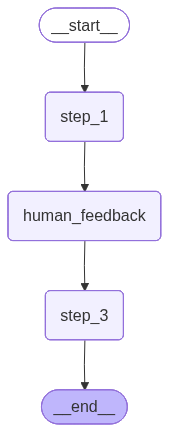

In [31]:
show_graph(graph)

In [32]:
# Input
initial_input = {"input": "hello world"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

---Step 1---
{'step_1': None}


---human_feedback---
{'__interrupt__': (Interrupt(value='Please provide feedback:', id='4c358104a85db2b152ed7751c01feb96'),)}




要从 interrupt **续跑**,我们使用 [`Command` 对象](https://langchain-ai.github.io/langgraph/how-tos/command/):

```python
graph.invoke(Command(resume="your value"), config={"configurable": {"thread_id": "..."}})
```

`resume` 里的值会作为 `interrupt(...)` 的 **返回值**,从暂停的那一行继续往下执行。

<div class="dark-warning" style="background:#2a2418; color:#fde68a; padding:12px 24px; border-left:4px solid #fbbf24; border-radius:4px; width:97%;"><style>.dark-warning strong{color:#f9a8d4;}</style>

**🔑 关键洞察:`Command` 不止用于 resume**

`Command` 还能在 node 内部 **直接返回**,同时做两件事:

- `update={...}` — 更新 state
- `goto="next_node"` — 跳到下一个节点(**替代** conditional_edges)

这是 LangGraph 一个非常优雅的设计 —— 详见 [`0_b_⭐️_edges_vs_Command.ipynb`](./0_b_⭐️_edges_vs_Command.ipynb)。

</div>

In [33]:
# Continue the graph execution
for event in graph.stream(
    Command(resume="go to step 3!"),
    thread,
    stream_mode="updates",
):
    print(event)
    print("\n")

---human_feedback---
{'human_feedback': {'user_feedback': 'go to step 3!'}}


---Step 3---
{'step_3': None}




## 🔭 Tracing(追踪)

用 LangChain 或 LangGraph 时,LangSmith 的日志记录 [开箱即用](https://docs.smith.langchain.com/observability/how_to_guides/trace_with_langgraph),只需要设两个环境变量:

```bash
export LANGSMITH_TRACING=true
export LANGSMITH_API_KEY="<your-langsmith-api-key>"
```

<div class="dark-cyan" style="background:#0f2729; color:#a5f3fc; padding:10px 24px; border-left:4px solid #22d3ee; border-radius:4px; width:97%;"><style>.dark-cyan strong{color:#fbbf24;}</style>

**🎯 LangSmith 在 ambient agent 里的核心地位**

ambient agent 在后台默默运行,你看不到它在干嘛。**LangSmith 是你唯一的窗口**:

- 看每一次 LLM 调用(prompt、token 数、延迟)
- 看每一次 tool 调用(参数、返回值)
- 看 graph 的每一个 node 执行情况
- 做 evaluation、跑 dataset、收集生产数据

**强烈建议**:从写第一行 LangGraph 代码起,就把 LangSmith 环境变量配上。零成本,巨大收益。

</div>

上面这次 agent 执行的 LangSmith trace:

🔗 https://smith.langchain.com/public/6f77014f-d054-44ed-aa2c-8b06ceab689f/r

你能看到 agent **接着上一次的对话状态继续往下走** —— 因为我们用了 checkpointer。

## 🚀 Deployment(部署)

也可以用 [LangGraph Platform](https://langchain-ai.github.io/langgraph/concepts/langgraph_platform/) 把图部署成生产服务。

它会启一个 [带 API 的 server](https://langchain-ai.github.io/langgraph/cloud/reference/api/api_ref.html),让你能通过 HTTP 跟图交互;同时提供一个交互式 IDE—— [LangGraph Studio](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/)。

### 📂 项目结构要求

只需要保证项目长这样([官方约定](https://langchain-ai.github.io/langgraph/concepts/application_structure/)):

```
my-app/
├── src/email_assistant/   # 所有项目代码
│   └── langgraph101.py    # 定义图的代码
├── .env                   # 环境变量
├── langgraph.json         # ⭐ LangGraph 配置文件(关键)
└── pyproject.toml         # 依赖
```

`langgraph.json` 里声明图的位置:

```json
{
  "langgraph101": "./src/email_assistant/langgraph_101.py:app"
}
```

### 🎛️ 部署模式

| 模式 | 命令 | checkpoint 存哪 | 适用 |
|------|------|-----------------|------|
| **本地开发** | `langgraph dev` | 本地文件系统 | 开发、调试 |
| **Self-Hosted** | 自己跑 Docker | 你自己的 Postgres | 完全控制 |
| **Cloud SaaS** | LangSmith UI 一键部署 | LangChain 托管的 Postgres | 生产、最省心 |

<div class="dark-orange" style="background:#2d2418; color:#fed7aa; padding:10px 24px; border-left:4px solid #fb923c; border-radius:4px; width:97%;"><style>.dark-orange strong{color:#67e8f9;}</style>

💡 **试一试**:在项目根目录(有 `langgraph.json` 的那层)跑 `langgraph dev`,然后用下面这个邮件测试:

```
Draft a response to my boss (boss@company.ai) confirming that I want to attend Interrupt!
```

</div>

你能在 LangGraph Studio 里看到图的可视化和 state 变化:

![langgraph_studio](img/langgraph_studio.png)

本地部署的 API 文档:

🔗 http://127.0.0.1:2024/docs

<div class="dark-success" style="background:#1a2e1f; color:#bbf7d0; padding:10px 24px; border-left:4px solid #4ade80; border-radius:4px; width:97%;"><style>.dark-success strong{color:#fbbf24;}</style>

## ✨ 本节带走

学完 Lesson 0,你掌握了 **6 个核心原语**:

1. **`init_chat_model`** —— 一行接入任何 LLM
2. **`@tool` + `bind_tools`** —— 让 LLM 能调用外部工具
3. **`StateGraph` 三件套** —— State / Node / Edge
4. **`create_react_agent`** —— 一行搭出 ReAct 循环
5. **`checkpointer + thread_id`** —— 持久化和多轮对话
6. **`interrupt + Command(resume=...)`** —— HITL 的物理基础

📎 配套笔记:[0_z_⭐️_本节精华](./0_z_⭐️_本节精华.ipynb) · [0_b_⭐️_edges_vs_Command](./0_b_⭐️_edges_vs_Command.ipynb) · [0_c_⭐️_工具类型大全](./0_c_⭐️_工具类型大全.ipynb)

</div>